In [3]:
# Cell 1: Directory Tree Exploration
import os

def print_directory_tree(startpath, max_depth=3):
    print(f"Exploring: {startpath}\n")
    for root, dirs, files in os.walk(startpath):
        # Calculate current depth
        level = root.replace(startpath, '').count(os.sep)
        if level > max_depth:
            continue
            
        indent = ' ' * 4 * level
        print(f'{indent}📂 {os.path.basename(root)}/')
        
        # Print a few sample files in each directory to see naming conventions
        subindent = ' ' * 4 * (level + 1)
        for f in files[:10]:
            print(f'{subindent}📄 {f}')
        
        if len(files) > 10:
            print(f'{subindent}... ({len(files)} total files)')

# The path you provided
base_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features'

if os.path.exists(base_path):
    print_directory_tree(base_path)
else:
    # If the path is slightly different, this will help us find it
    print(f"Path not found: {base_path}")
    print("Available in /kaggle/input:")
    print(os.listdir('/kaggle/input'))

Exploring: /kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features

📂 circuitnet-preprocessed-features/
    📂 metadata/
        📄 dataset_info.json
        📄 design_names.txt
        📄 input_channels.json
        📄 shard_index.json
        📄 output_channels.json
        📄 channel_statistics.json
    📂 shards/
        📄 shard_092.npz
        📄 shard_087.npz
        📄 shard_100.npz
        📄 shard_039.npz
        📄 shard_094.npz
        📄 shard_052.npz
        📄 shard_099.npz
        📄 shard_009.npz
        📄 shard_019.npz
        📄 shard_054.npz
        ... (103 total files)
    📂 documentation/
        📄 README.md
        📄 example_usage.py
    📂 sample_visualizations/
        📄 mask_demonstration.png
        📄 sample_all_channels.png


In [4]:
import numpy as np
import json
import os

base_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features'

# 1. Look for feature mapping in JSON files
print("--- Metadata Check ---")
metadata_files = [f for f in os.listdir(base_path) if f.endswith('.json')]
for meta in metadata_files:
    with open(os.path.join(base_path, meta), 'r') as f:
        print(f"Content of {meta}:")
        print(json.dumps(json.load(f), indent=2))

# 2. Inspect a single shard
print("\n--- Shard Inspection ---")
shard_path = os.path.join(base_path, 'shard_0.npz') # Adjust name if different
if os.path.exists(shard_path):
    shard = np.load(shard_path)
    print(f"Keys in shard: {list(shard.keys())}")
    
    for key in shard.keys():
        sample_data = shard[key]
        print(f"Key: {key:15} | Shape: {sample_data.shape} | Dtype: {sample_data.dtype}")
        # If it's a large 4D array (N, C, H, W), let's see the range
        if len(sample_data.shape) >= 2:
            print(f"      Min: {sample_data.min():.4f} | Max: {sample_data.max():.4f} | Mean: {sample_data.mean():.4f}")
else:
    # If shard_0.npz doesn't exist, list the files in the main dir to get the exact name
    print(f"shard_0.npz not found. Available files: {os.listdir(base_path)[:5]}")

--- Metadata Check ---

--- Shard Inspection ---
shard_0.npz not found. Available files: ['metadata', 'shards', 'documentation', 'sample_visualizations']


In [5]:
# Cell 2: Inspecting dataset_info.json
import json

file_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/metadata/dataset_info.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
        print(json.dumps(data, indent=2))
except FileNotFoundError:
    print(f"File not found at {file_path}")

{
  "dataset_name": "CircuitNet N28 Routability Features (Preprocessed)",
  "version": "1.0",
  "source": "CircuitNet N28 benchmark",
  "technology_node": "28nm",
  "description": "Grid-based physical design features for congestion prediction. Each design is represented as a 320x320 grid with zero-padding for smaller designs. Features include placement-derived inputs (cell density, macro regions, RUDY) and routing outcomes (GR utilization, overflow, DRC violations).",
  "data_format": {
    "file_format": "NPZ (compressed NumPy arrays)",
    "shard_size": "100 samples per shard (last shard may have fewer)",
    "grid_size": [
      320,
      320
    ],
    "padding": "Zero-padded to 320x320, anchored at top-left (0,0)",
    "data_type": "float32 for features, uint8 for mask"
  },
  "shard_structure": {
    "X": {
      "shape": "(N, 7, 320, 320)",
      "dtype": "float32",
      "description": "Input feature channels"
    },
    "Y": {
      "shape": "(N, 5, 320, 320)",
      "dtype":

In [6]:
# Cell 3: Inspecting input_channels.json
import json

file_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/metadata/input_channels.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
        print(json.dumps(data, indent=2))
except FileNotFoundError:
    print(f"File not found at {file_path}")

{
  "description": "Input feature channels (placement-derived features)",
  "num_channels": 7,
  "channels": [
    {
      "index": 0,
      "name": "macro_region",
      "description": "Binary mask indicating macro blockage regions (1=macro, 0=placeable)",
      "value_range": [
        0.0,
        1.0
      ],
      "data_type": "binary"
    },
    {
      "index": 1,
      "name": "cell_density",
      "description": "Number of standard cells per GCell",
      "value_range": [
        0.0,
        143.0
      ],
      "data_type": "integer"
    },
    {
      "index": 2,
      "name": "RUDY_standard",
      "description": "Standard RUDY routing demand estimation",
      "value_range": [
        0.0,
        0.0915
      ],
      "data_type": "continuous"
    },
    {
      "index": 3,
      "name": "RUDY_short",
      "description": "RUDY for short nets",
      "value_range": [
        0.0,
        0.0089
      ],
      "data_type": "continuous"
    },
    {
      "index": 4,
     

In [7]:
# Cell 4: Inspecting output_channels.json
import json

file_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/metadata/output_channels.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
        print(json.dumps(data, indent=2))
except FileNotFoundError:
    print(f"File not found at {file_path}")

{
  "description": "Output target channels (routing outcomes)",
  "num_channels": 5,
  "channels": [
    {
      "index": 0,
      "name": "GR_horizontal_utilization",
      "description": "Horizontal global routing track utilization (0-1 = normal, >1 = overflow)",
      "value_range": [
        0.0,
        23.3333
      ],
      "data_type": "continuous"
    },
    {
      "index": 1,
      "name": "GR_vertical_utilization",
      "description": "Vertical global routing track utilization (0-1 = normal, >1 = overflow)",
      "value_range": [
        0.0,
        67.5
      ],
      "data_type": "continuous"
    },
    {
      "index": 2,
      "name": "GR_horizontal_overflow",
      "description": "Horizontal global routing overflow (missing tracks)",
      "value_range": [
        0.0,
        97.0
      ],
      "data_type": "continuous_sparse"
    },
    {
      "index": 3,
      "name": "GR_vertical_overflow",
      "description": "Vertical global routing overflow (missing tracks

In [8]:
# Cell 5: Inspecting channel_statistics.json
import json

file_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/metadata/channel_statistics.json'

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
        print(json.dumps(data, indent=2))
except FileNotFoundError:
    print(f"File not found at {file_path}")

{
  "inputs": {
    "macro_region": {
      "min": 0.0,
      "max": 1.0
    },
    "cell_density": {
      "min": 0.0,
      "max": 143.0
    },
    "RUDY_standard": {
      "min": 0.0,
      "max": 0.09149917960166931
    },
    "RUDY_short": {
      "min": 0.0,
      "max": 0.008873010985553265
    },
    "RUDY_long": {
      "min": 0.0,
      "max": 0.09053557366132736
    },
    "RUDY_pin": {
      "min": 0.0,
      "max": 0.037473954260349274
    },
    "RUDY_pin_long": {
      "min": 0.0,
      "max": 0.03541681542992592
    }
  },
  "outputs": {
    "GR_h_util": {
      "min": 0.0,
      "max": 23.33333396911621
    },
    "GR_v_util": {
      "min": 0.0,
      "max": 67.5
    },
    "GR_h_overflow": {
      "min": 0.0,
      "max": 97.0
    },
    "GR_v_overflow": {
      "min": 0.0,
      "max": 125.0
    },
    "DRC_violations": {
      "min": 0.0,
      "max": 41433.0
    }
  }
}


In [9]:
# Cell 6: Reading README.md
file_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/documentation/README.md'

try:
    with open(file_path, 'r') as f:
        print(f.read())
except FileNotFoundError:
    print(f"File not found at {file_path}")

# CircuitNet N28 Routability Features Dataset

## Overview

This dataset contains preprocessed grid-based physical design features from the CircuitNet N28 benchmark for congestion prediction and routability analysis tasks.

- **Total Samples**: 10,242 designs
- **Grid Size**: 320 × 320 (zero-padded)
- **Format**: NPZ shards (100 samples per shard)
- **Technology Node**: 28nm

---

## Dataset Structure
```
circuitnet_features_shards/
├── shards/                      # 103 NPZ files containing preprocessed data
│   ├── shard_000.npz
│   ├── shard_001.npz
│   └── ...
├── metadata/                    # JSON files describing the dataset
│   ├── dataset_info.json       # Overall dataset information
│   ├── input_channels.json     # Input channel descriptions
│   ├── output_channels.json    # Output channel descriptions
│   ├── channel_statistics.json # Min/max statistics
│   ├── shard_index.json        # Shard-to-sample mapping
│   └── design_names.txt        # List of all design names
├── d

In [10]:
# Cell 7: Reading example_usage.py
file_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/documentation/example_usage.py'

try:
    with open(file_path, 'r') as f:
        print(f.read())
except FileNotFoundError:
    print(f"File not found at {file_path}")

#!/usr/bin/env python3
"""
Example usage script for CircuitNet N28 Routability Features Dataset
"""

import numpy as np
import matplotlib.pyplot as plt
import json

# ============================================================================
# EXAMPLE 1: Load and inspect a single shard
# ============================================================================

def example_load_shard():
    print("="*80)
    print("EXAMPLE 1: Loading a shard")
    print("="*80)
    
    # Load shard
    shard = np.load('shards/shard_000.npz')
    
    print(f"Keys: {list(shard.keys())}")
    print(f"X shape: {shard['X'].shape}")
    print(f"Y shape: {shard['Y'].shape}")
    print(f"Mask shape: {shard['mask'].shape}")
    print(f"Number of samples: {len(shard['names'])}")
    print(f"First design: {shard['names'][0]}")
    

# ============================================================================
# EXAMPLE 2: Select specific input/output channels
# ============================================

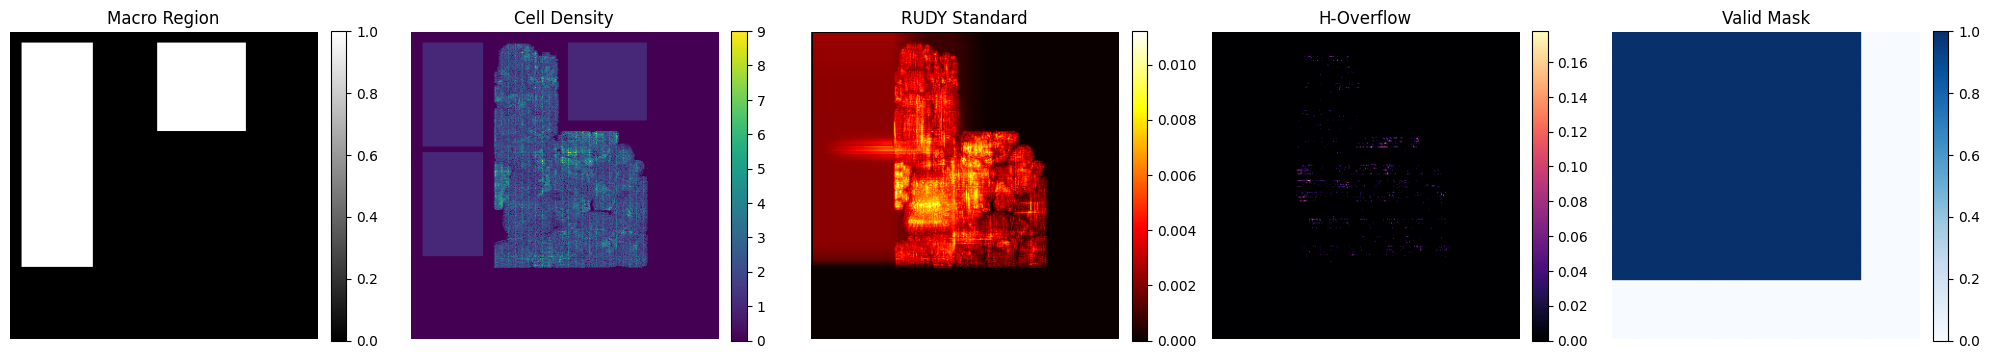

Design Name: 1-RISCY-a-1-c2-u0.7-m1-p1-f0
Max Overflow in this sample: 0.17777778208255768


In [11]:
# Cell 8: Visualizing features and targets from a single shard
import numpy as np
import matplotlib.pyplot as plt
import os

shard_path = '/kaggle/input/datasets/chupparetti/circuitnet-preprocessed-features/shards/shard_000.npz'
data = np.load(shard_path)

# Pick a sample index (0 to 99)
idx = 0

# Extract channels based on our metadata knowledge
macro = data['X'][idx, 0]
cell_den = data['X'][idx, 1]
rudy_std = data['X'][idx, 2]
over_h = data['Y'][idx, 2]
mask = data['mask'][idx]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Plotting
imgs = [macro, cell_den, rudy_std, over_h, mask]
titles = ['Macro Region', 'Cell Density', 'RUDY Standard', 'H-Overflow', 'Valid Mask']
cmaps = ['gray', 'viridis', 'hot', 'magma', 'Blues']

for i, ax in enumerate(axes):
    im = ax.imshow(imgs[i], cmap=cmaps[i])
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Design Name: {data['names'][idx]}")
print(f"Max Overflow in this sample: {over_h.max()}")